[SAVED] ./plots/Heatmap_24labels_Top24_merged_ABS.png


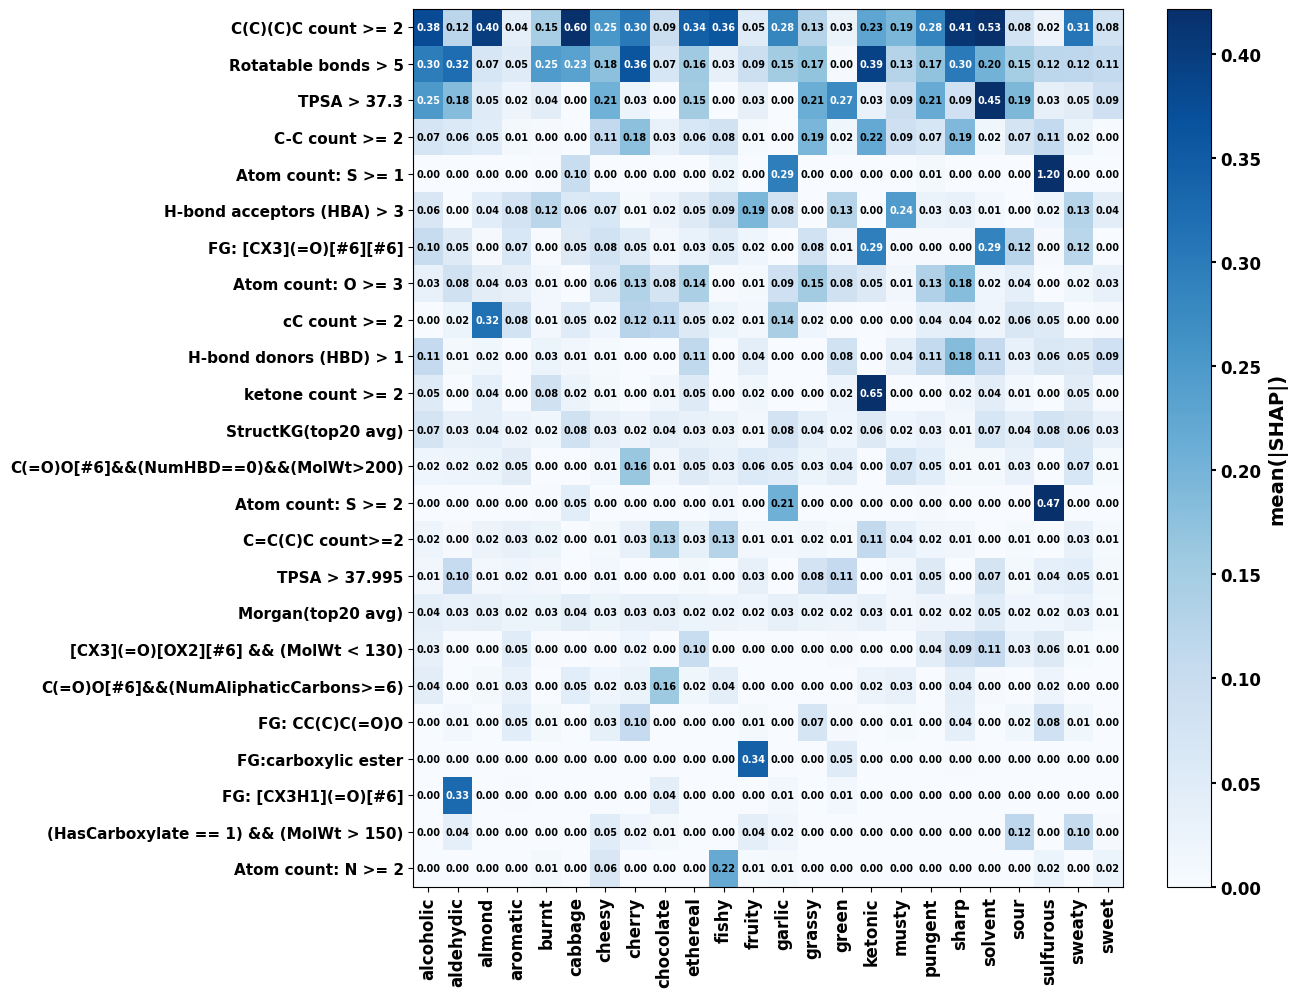

In [2]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_CSV = "./shap_cache_and_plots_24labels/plots/Heatmap_24labels_Top24_merged.csv"

OUT_DIR = "./plots"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PNG = os.path.join(OUT_DIR, "Heatmap_24labels_Top24_merged_ABS.png")
DPI = 600

def plot_heatmap_abs(df_abs: pd.DataFrame,
                     out_png: str,
                     dpi: int = 600,
                     show: bool = True,
                     save: bool = True,
                     text_fmt: str = "{:.2f}",
                     use_percentile_vmax: bool = True):
    """
    - 横轴：labels（气味描述词）
    - 纵轴：features（Top特征）
    - 数值：abs 后的 mean(|SHAP|)
    - 深色格子文字白色，浅色格子文字黑色
    - 所有字体加粗
    """
    # 绝对值 + 转置：行features，列labels
    df_plot = df_abs.abs().T
    mat = df_plot.values.astype(float)

    row_names = df_plot.index.tolist()
    col_names = df_plot.columns.tolist()

    # 字体全局加粗（可选）
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"

    # 颜色范围：防止极端值把整体压得太浅（推荐）
    vmin = 0.0
    if use_percentile_vmax:
        vmax = float(np.percentile(mat, 99)) if np.any(mat > 0) else 1.0
        vmax = max(vmax, 1e-12)
    else:
        vmax = float(np.max(mat)) if np.any(mat > 0) else 1.0

    # 图尺寸
    fig_w = max(10, 0.55 * len(col_names))
    fig_h = max(6,  0.42 * len(row_names))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(mat, aspect="auto", cmap="Blues", vmin=vmin, vmax=vmax)


    # colorbar
    cbar = fig.colorbar(im, ax=ax)
    
    # label 字体（可调）
    cbar.set_label("mean(|SHAP|)", fontweight="bold", fontsize=14)
    
    # 刻度字体变大 + 加粗（可调）
    cbar.ax.tick_params(labelsize=12, width=1.5)   # labelsize 控制刻度字号
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight("bold")



    
    # 坐标轴刻度
    ax.set_xticks(np.arange(len(col_names)))
    ax.set_yticks(np.arange(len(row_names)))
    ax.set_xticklabels(col_names, rotation=90, fontsize=12, fontweight="bold")
    ax.set_yticklabels(row_names, fontsize=11, fontweight="bold")

    # 自动判断文字颜色：用归一化后的阈值
    # 阈值=0.55 更适合 Blues（偏深才白字），你可调 0.5~0.65
    threshold = 0.55
    # 归一化到0~1
    denom = (vmax - vmin) if (vmax - vmin) > 0 else 1.0

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            norm = (val - vmin) / denom
            txt_color = "white" if norm >= threshold else "black"
            ax.text(
                j, i, text_fmt.format(val),
                ha="center", va="center",
                fontsize=7,
                fontweight="bold",
                color=txt_color
            )

    fig.tight_layout()

    if save:
        fig.savefig(out_png, dpi=dpi, bbox_inches="tight")
        print("[SAVED]", out_png)

    if show:
        plt.show()

    plt.close(fig)


def main():
    df = pd.read_csv(IN_CSV, index_col=0)  # 行=labels，列=features
    plot_heatmap_abs(df, OUT_PNG, dpi=DPI, show=True, save=True)

if __name__ == "__main__":
    main()
